## 1. Data collection and EDA

In [1]:
# importing various libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from plotly.subplots import make_subplots
# importing the dataset
df = pd.read_csv('../../data/raw/Fraudtrain.csv')

In [2]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
# dropping the extra index column
df = df.iloc[:, 1:]

In [4]:
# Numerical statistics
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [5]:
# categorical statistics
df.describe(include=['object'])

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675
unique,1274791,693,14,352,481,2,983,894,51,494,968,1296675
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,0069 Robin Brooks Apt. 695,Birmingham,TX,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9
freq,4,4403,131659,26669,28794,709863,3123,5617,94876,9779,5636,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop          

In [7]:
# checking for null values
df.isnull().sum().any()

False

In [8]:
# checking for duplicates
df.duplicated().any()

False

No Frauds 99.42 % of the dataset
Frauds 0.58 % of the dataset


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

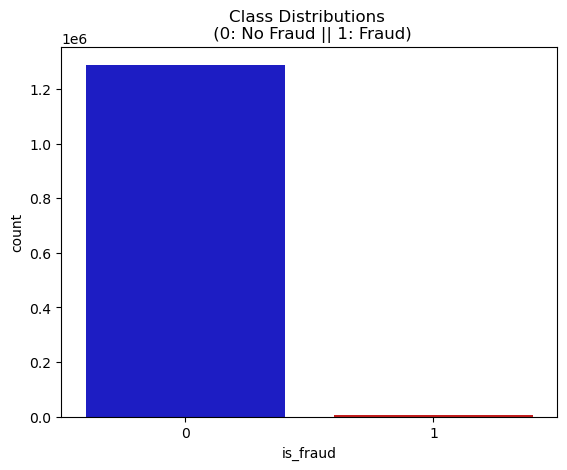

In [9]:
# Checking for data imbalance 
print('No Frauds', round(df['is_fraud'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['is_fraud'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

# visualising the distribution 
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='is_fraud', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=12)

In [10]:
# Correlation matrix
correlation_matrix = df.corr()

C:\Users\Black\AppData\Local\Temp\ipykernel_51828\1318360892.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


Text(0.5, 1.0, 'Correlation Matrix')

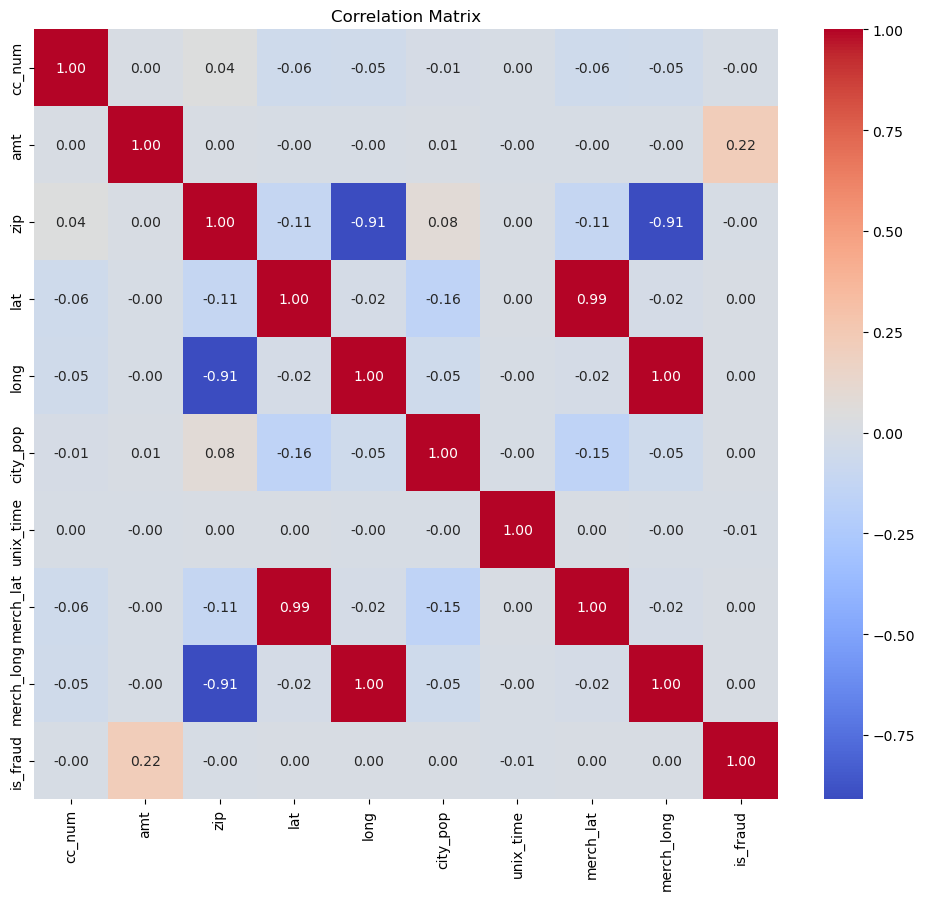

In [11]:
# Plotting the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')

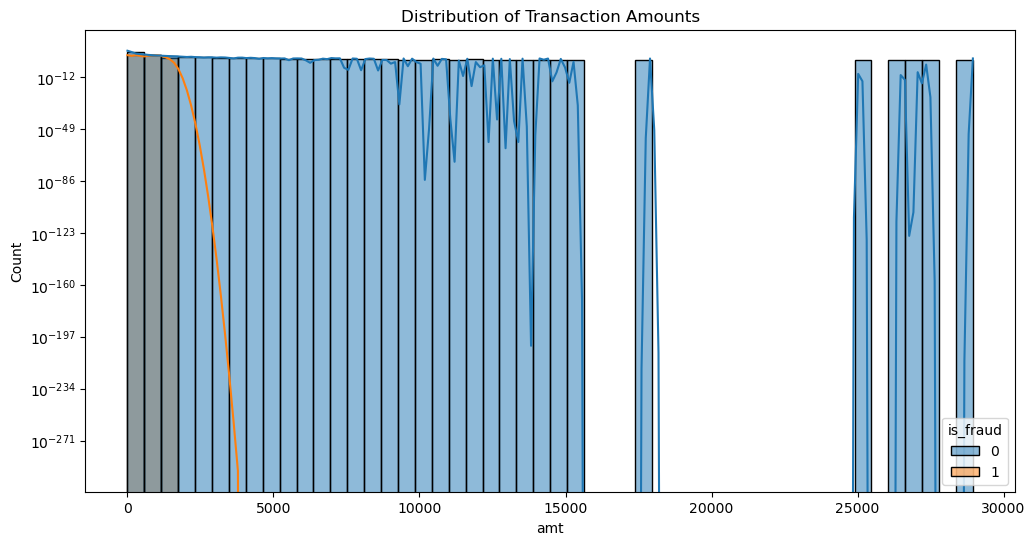

In [12]:
# Visualizing the distribution of transaction amounts for fraudulent vs. non-fraudulent transactions
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='amt', hue='is_fraud', bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.yscale('log')

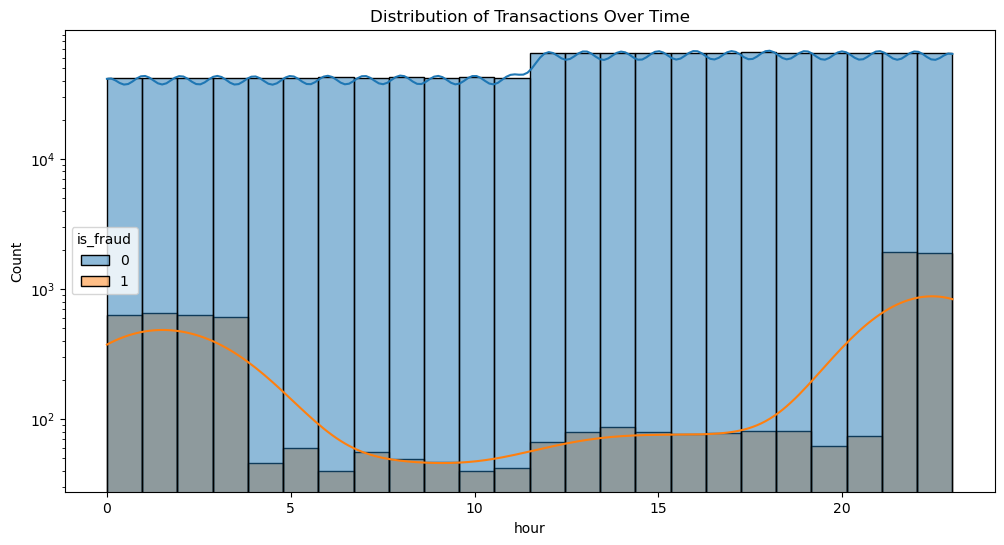

In [13]:
# Visualizing the distribution of transactions over time
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='hour', hue='is_fraud', bins=24, kde=True)
plt.title('Distribution of Transactions Over Time')
plt.yscale('log')

Text(0.5, 1.0, 'Geographic Distribution of Transactions')

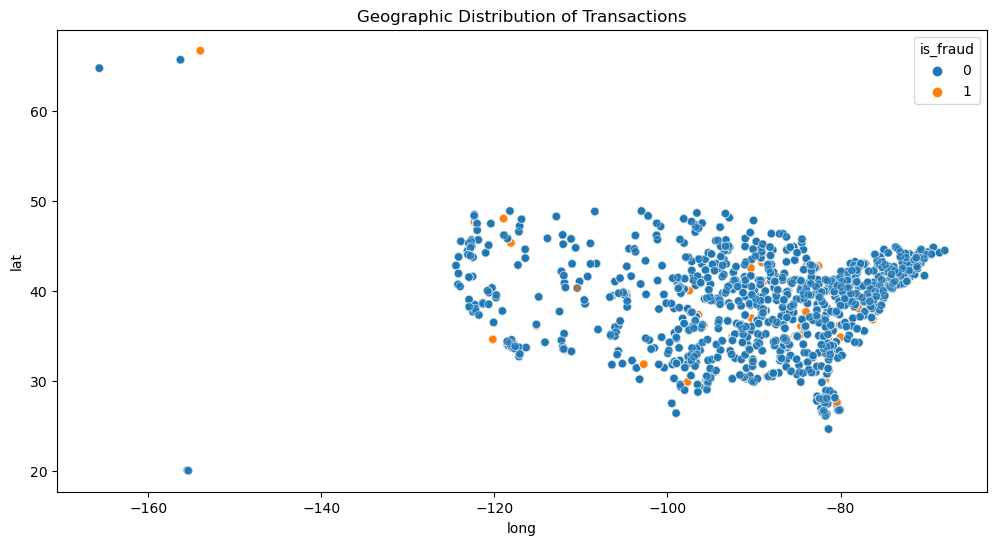

In [14]:
# Visualizing the geographic distribution of transactions
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='long', y='lat', hue='is_fraud', alpha=0.5)
plt.title('Geographic Distribution of Transactions')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]),
 [Text(0, 0, 'NY'),
  Text(1, 0, 'TX'),
  Text(2, 0, 'PA'),
  Text(3, 0, 'CA'),
  Text(4, 0, 'OH'),
  Text(5, 0, 'FL'),
  Text(6, 0, 'IL'),
  Text(7, 0, 'MI'),
  Text(8, 0, 'AL'),
  Text(9, 0, 'MN'),
  Text(10, 0, 'VA'),
  Text(11, 0, 'SC'),
  Text(12, 0, 'MO'),
  Text(13, 0, 'NE'),
  Text(14, 0, 'WI'),
  Text(15, 0, 'AR'),
  Text(16, 0, 'MD'),
  Text(17, 0, 'KS'),
  Text(18, 0, 'KY'),
  Text(19, 0, 'OR'),
  Text(20, 0, 'NC'),
  Text(21, 0, 'GA'),
  Text(22, 0, 'WV'),
  Text(23, 0, 'OK'),
  Text(24, 0, 'IA'),
  Text(25, 0, 'IN'),
  Text(26, 0, 'TN'),
  Text(27, 0, 'ME'),
  Text(28, 0, 'NJ'),
  Text(29, 0, 'MS'),
  Text(30, 0, 'CO'),
  Text(31, 0, 'WY'),
  Text(32, 0, 'WA'),
  Text(33, 0, 'LA'),
  Text(34, 0, 'NM'),
  Text(35, 0, 'SD'),
  Text(36, 0, 'VT'),
  T

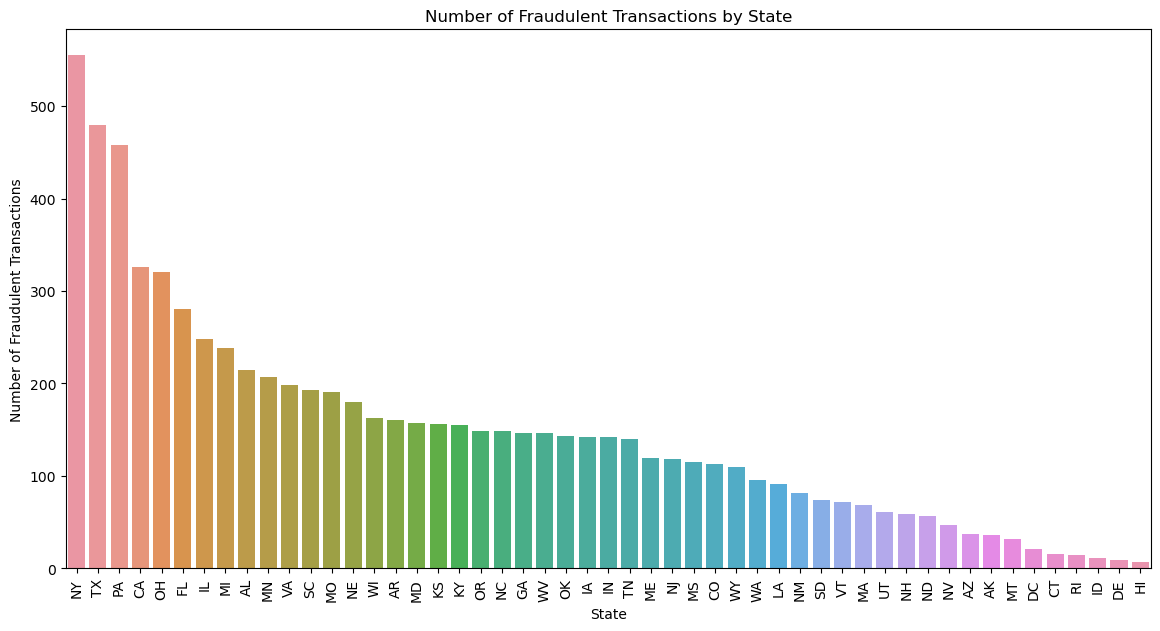

In [15]:
# Calculate the number of fraudulent transactions by state
fraud_by_state = df[df['is_fraud'] == 1]['state'].value_counts()

# Plot the fraud trends by state
plt.figure(figsize=(14, 7))
sns.barplot(x=fraud_by_state.index, y=fraud_by_state.values)
plt.title('Number of Fraudulent Transactions by State')
plt.xlabel('State')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90)

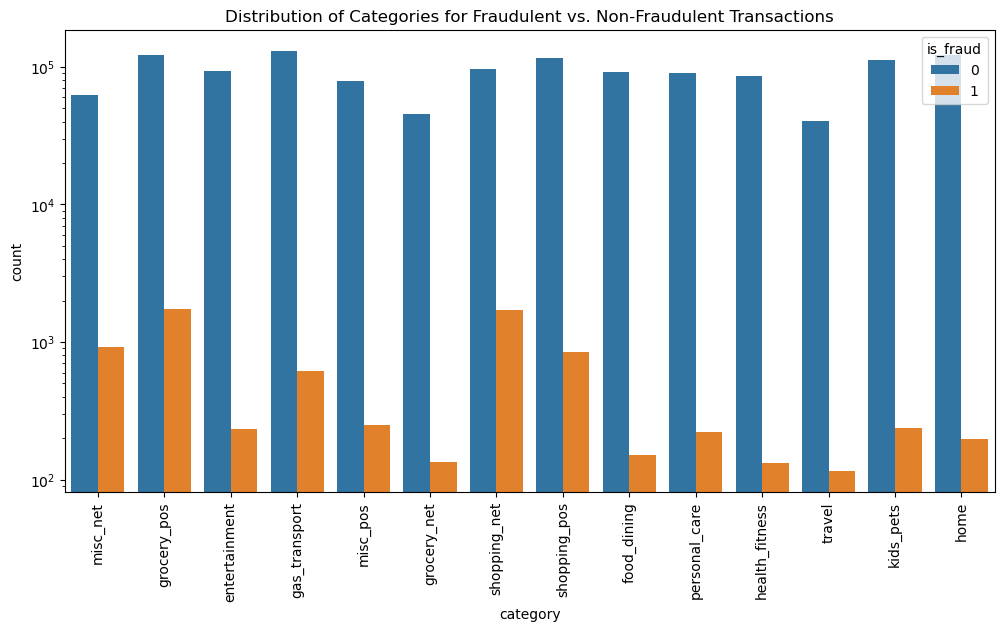

In [16]:
# Visualizing the distribution of categories for fraudulent vs. non-fraudulent transactions
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='category', hue='is_fraud')
plt.title('Distribution of Categories for Fraudulent vs. Non-Fraudulent Transactions')
plt.xticks(rotation=90)
plt.yscale('log')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'fraud_Rau and Sons'),
  Text(1, 0, 'fraud_Cormier LLC'),
  Text(2, 0, 'fraud_Kozey-Boehm'),
  Text(3, 0, 'fraud_Doyle Ltd'),
  Text(4, 0, 'fraud_Vandervort-Funk'),
  Text(5, 0, 'fraud_Kilback LLC'),
  Text(6, 0, 'fraud_Padberg-Welch'),
  Text(7, 0, 'fraud_Kuhn LLC'),
  Text(8, 0, 'fraud_Terry-Huel'),
  Text(9, 0, 'fraud_Koepp-Witting'),
  Text(10, 0, 'fraud_Goyette Inc'),
  Text(11, 0, 'fraud_Jast Ltd'),
  Text(12, 0, 'fraud_Kiehn-Emmerich'),
  Text(13, 0, 'fraud_Kerluke-Abshire'),
  Text(14, 0, 'fraud_Schmeler, Bashirian and Price'),
  Text(15, 0, 'fraud_McDermott-Weimann'),
  Text(16, 0, 'fraud_Hudson-Ratke'),
  Text(17, 0, 'fraud_Gleason-Macejkovic'),
  Text(18, 0, 'fraud_Moen, Reinger and Murphy'),
  Text(19, 0, 'fraud_Boyer PLC')])

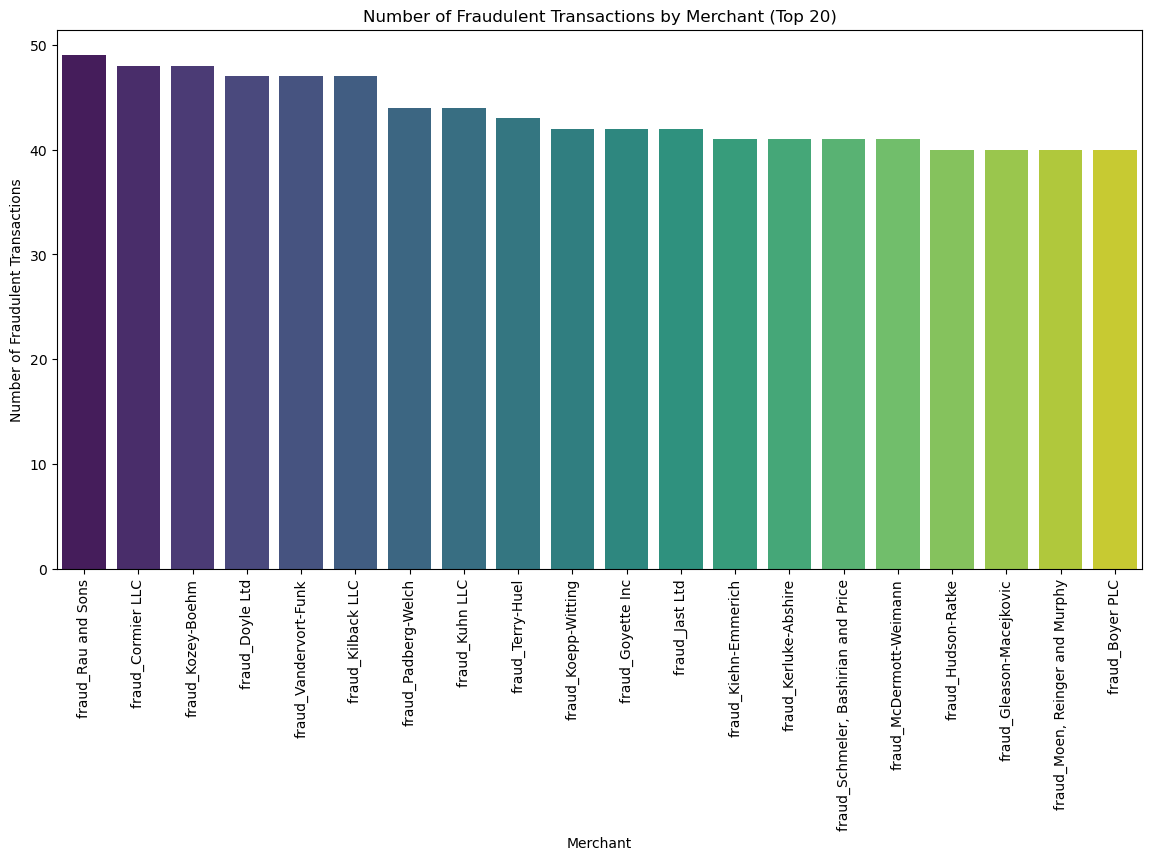

In [17]:
# Calculate the number of fraudulent transactions by merchant
fraud_by_merchant = df[df['is_fraud'] == 1]['merchant'].value_counts()

# Get the top 20 merchants with the highest number of fraudulent transactions
top_20_fraud_by_merchant = fraud_by_merchant.head(20)

# Plot the fraud distribution by merchant
plt.figure(figsize=(14, 7))
sns.barplot(x=top_20_fraud_by_merchant.index, y=top_20_fraud_by_merchant.values, palette="viridis")
plt.title('Number of Fraudulent Transactions by Merchant (Top 20)')
plt.xlabel('Merchant')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]),
 [Text(0, 0, '14'),
  Text(1, 0, '15'),
  Text(2, 0, '16'),
  Text(3, 0, '18'),
  Text(4, 0, '19'),
  Text(5, 0, '20'),
  Text(6, 0, '21'),
  Text(7, 0, '22'),
  Text(8, 0, '23'),
  Text(9, 0, '24'),
  Text(10, 0, '25'),
  Text(11, 0, '26'),
  Text(12, 0, '27'),
  Text(13, 0, '28'),
  Text(14, 0, '29'),
  Text(15, 0, '30'),
  Text(16, 0, '31'),
  Text(17, 0, '32'),
  Text(18, 0, '33'),
  Text(19, 0, '34'),
  Text(20, 0, '35'),
  Text(21, 0, '36'),
  Text(22, 0, '37'),
  Text(23, 0, '38'),
  Text(24, 0, '39'),
  Text(25, 0, '40'),
  Text(26, 0, '41'),
  Text(27, 0, '42'),
  Text(28, 0, '43'),
  Text(29, 0, '44'),
  Text(30, 0, '45'

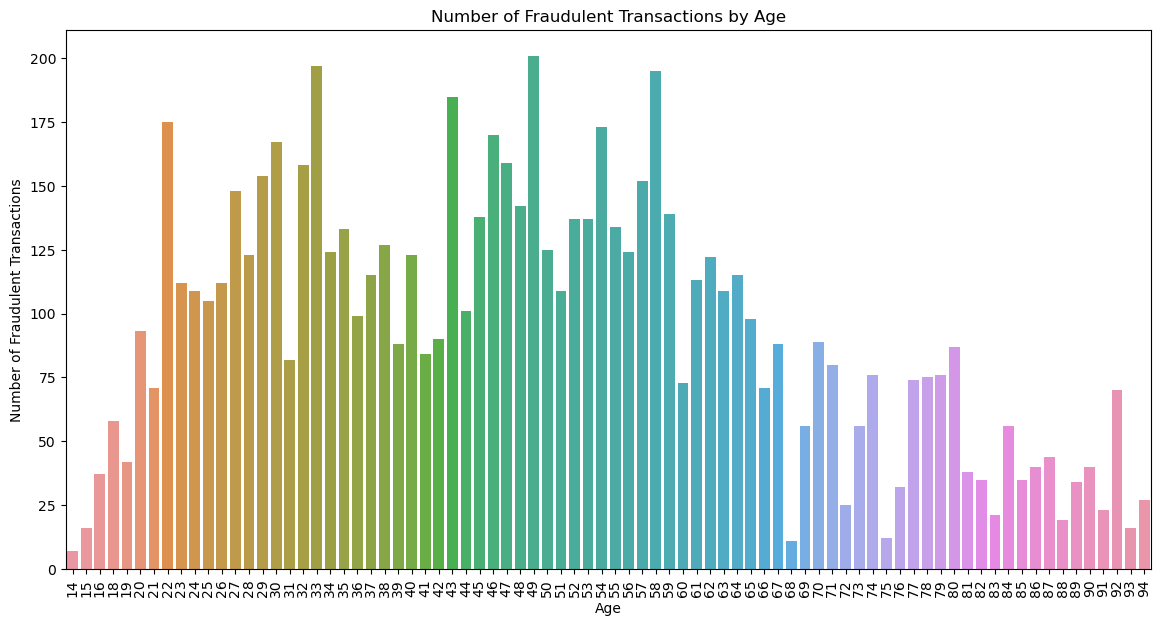

In [18]:
# Calculate the age of cardholders
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

# Calculate the number of fraudulent transactions by age
fraud_by_age = df[df['is_fraud'] == 1]['age'].value_counts().sort_index()

# Plot the fraud distribution by age
plt.figure(figsize=(14, 7))
sns.barplot(x=fraud_by_age.index, y=fraud_by_age.values)
plt.title('Number of Fraudulent Transactions by Age')
plt.xlabel('Age')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90)

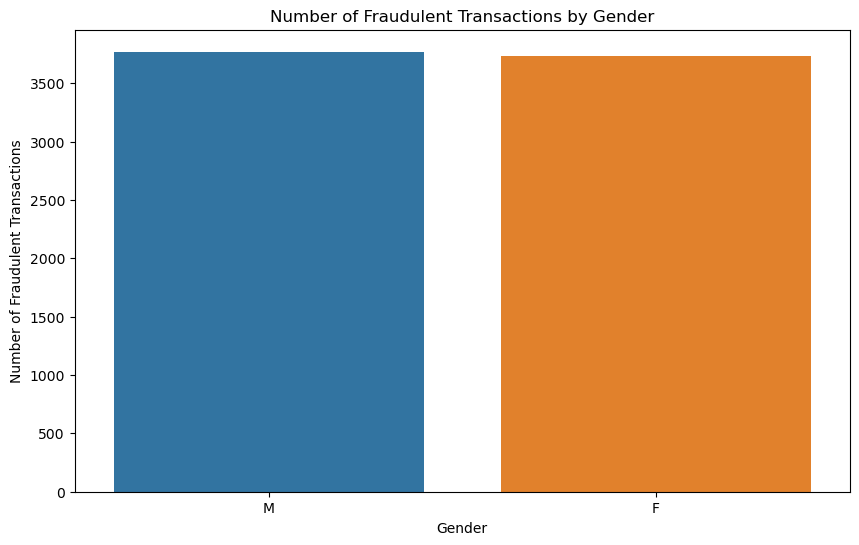

In [19]:
# Calculate the number of fraudulent transactions by gender
fraud_by_gender = df[df['is_fraud'] == 1]['gender'].value_counts()

# Plot the fraud trends by gender
plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_by_gender.index, y=fraud_by_gender.values)
plt.title('Number of Fraudulent Transactions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

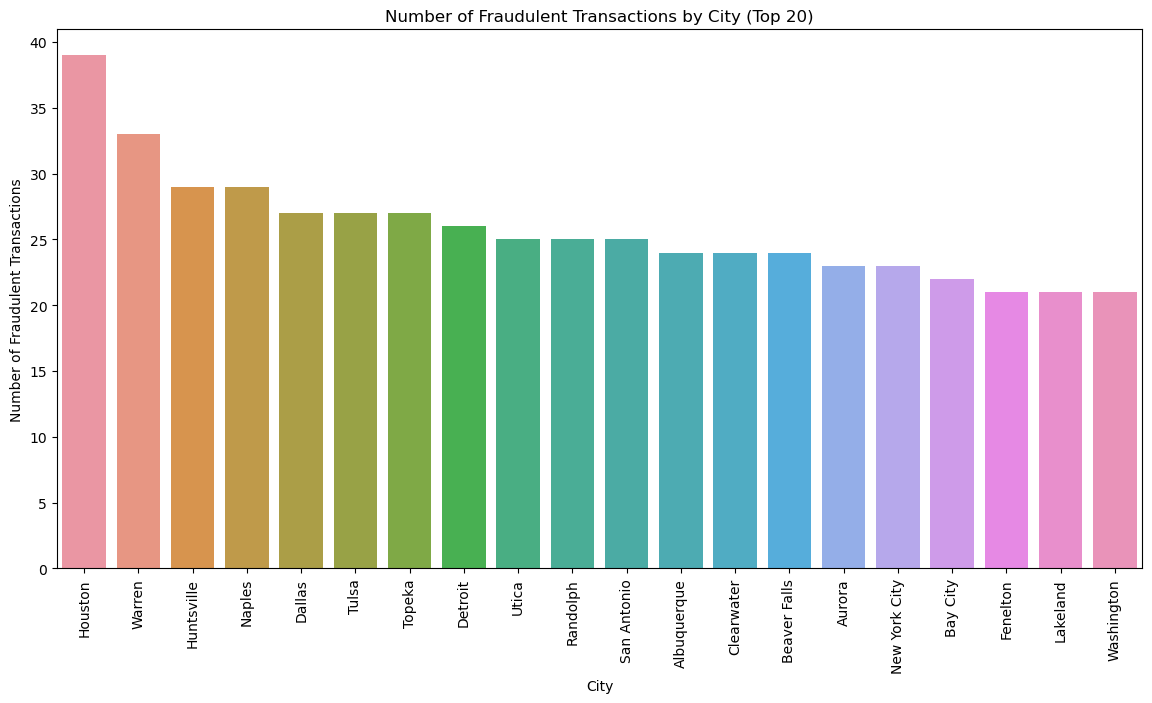

In [20]:
# Calculate the number of fraudulent transactions by city
fraud_by_city = df[df['is_fraud'] == 1]['city'].value_counts().head(20)  # Top 20 cities with most frauds

# Plot the fraud trends by city
plt.figure(figsize=(14, 7))
sns.barplot(x=fraud_by_city.index, y=fraud_by_city.values)
plt.title('Number of Fraudulent Transactions by City (Top 20)')
plt.xlabel('City')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90)
plt.show()

Text(145.72222222222223, 0.5, 'City')

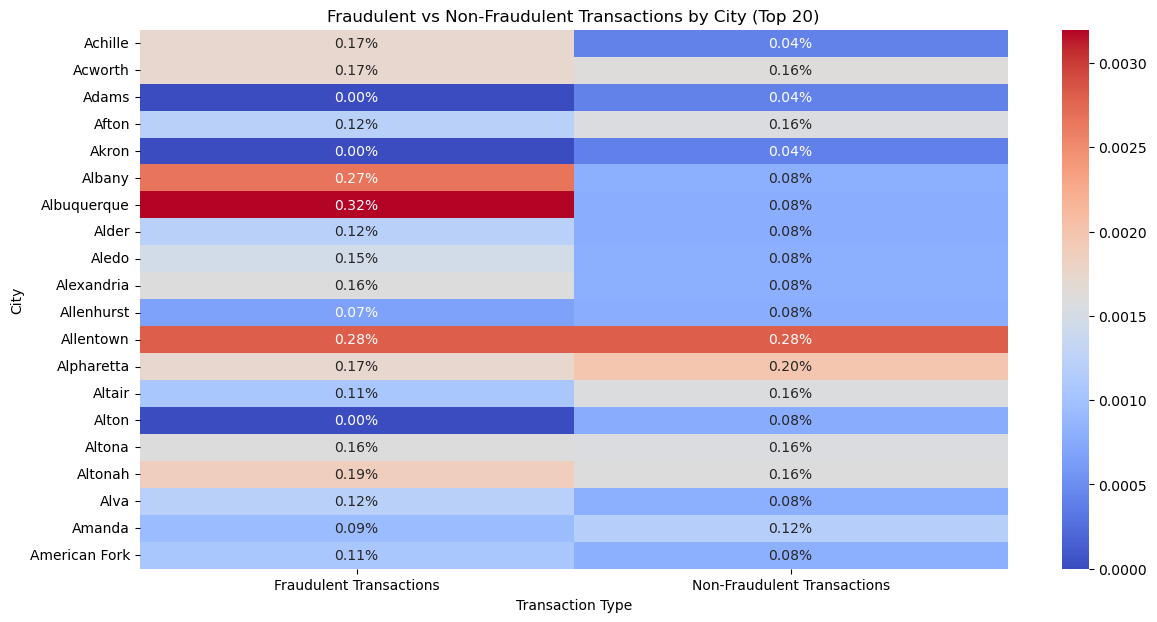

In [21]:
# Calculate the number of fraudulent transactions by city
fraud_by_city = df[df['is_fraud'] == 1]['city'].value_counts()
non_fraud_by_city = df[df['is_fraud'] == 0]['city'].value_counts()

# Combine into a DataFrame for comparison
fraud_comparison = pd.DataFrame({
    'Fraudulent Transactions': fraud_by_city,
    'Non-Fraudulent Transactions': non_fraud_by_city
}).fillna(0)

# Normalize the data for heatmap
fraud_comparison['Fraudulent Transactions'] = fraud_comparison['Fraudulent Transactions'] / fraud_comparison['Fraudulent Transactions'].sum()
fraud_comparison['Non-Fraudulent Transactions'] = fraud_comparison['Non-Fraudulent Transactions'] / fraud_comparison['Non-Fraudulent Transactions'].sum()

# Plot heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(fraud_comparison.head(20), annot=True, fmt='.2%', cmap='coolwarm')
plt.title('Fraudulent vs Non-Fraudulent Transactions by City (Top 20)')
plt.xlabel('Transaction Type')
plt.ylabel('City')

Text(0, 0.5, 'Job')

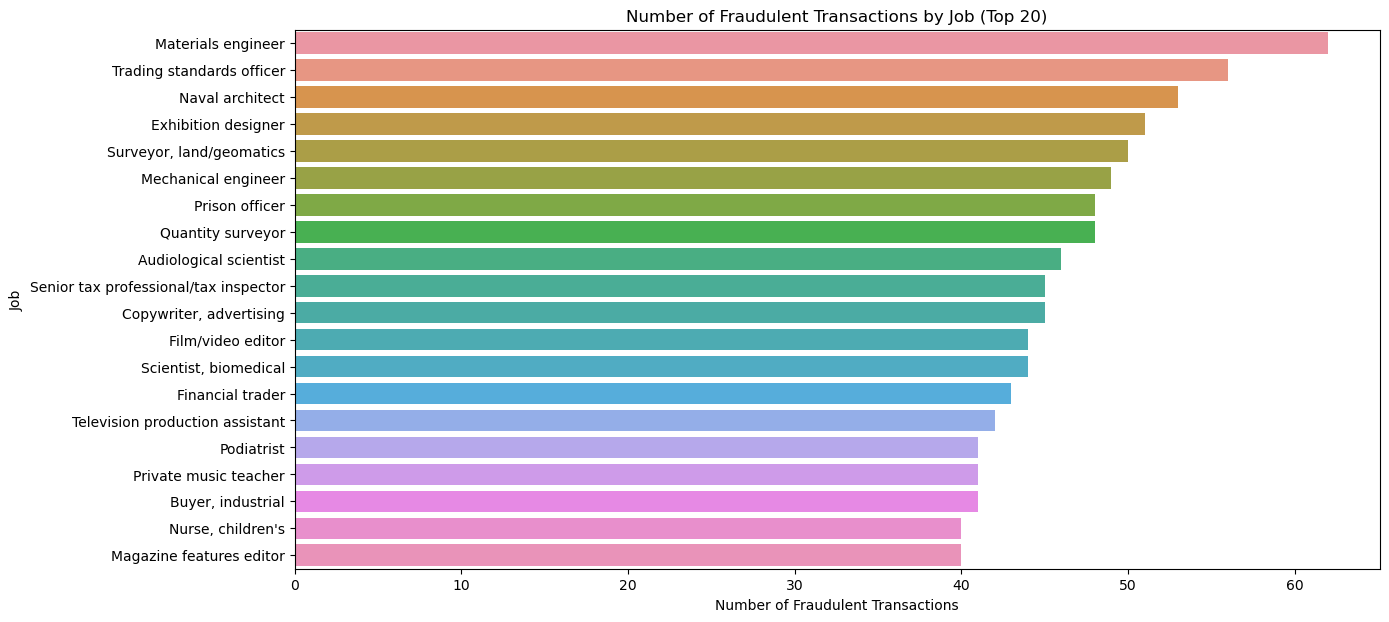

In [22]:
# Calculate the number of fraudulent transactions by job
fraud_by_job = df[df['is_fraud'] == 1]['job'].value_counts().head(20)  # Top 20 jobs with most frauds

# Plot the fraud trends by job
plt.figure(figsize=(14, 7))
sns.barplot(x=fraud_by_job.values, y=fraud_by_job.index)
plt.title('Number of Fraudulent Transactions by Job (Top 20)')
plt.xlabel('Number of Fraudulent Transactions')
plt.ylabel('Job')

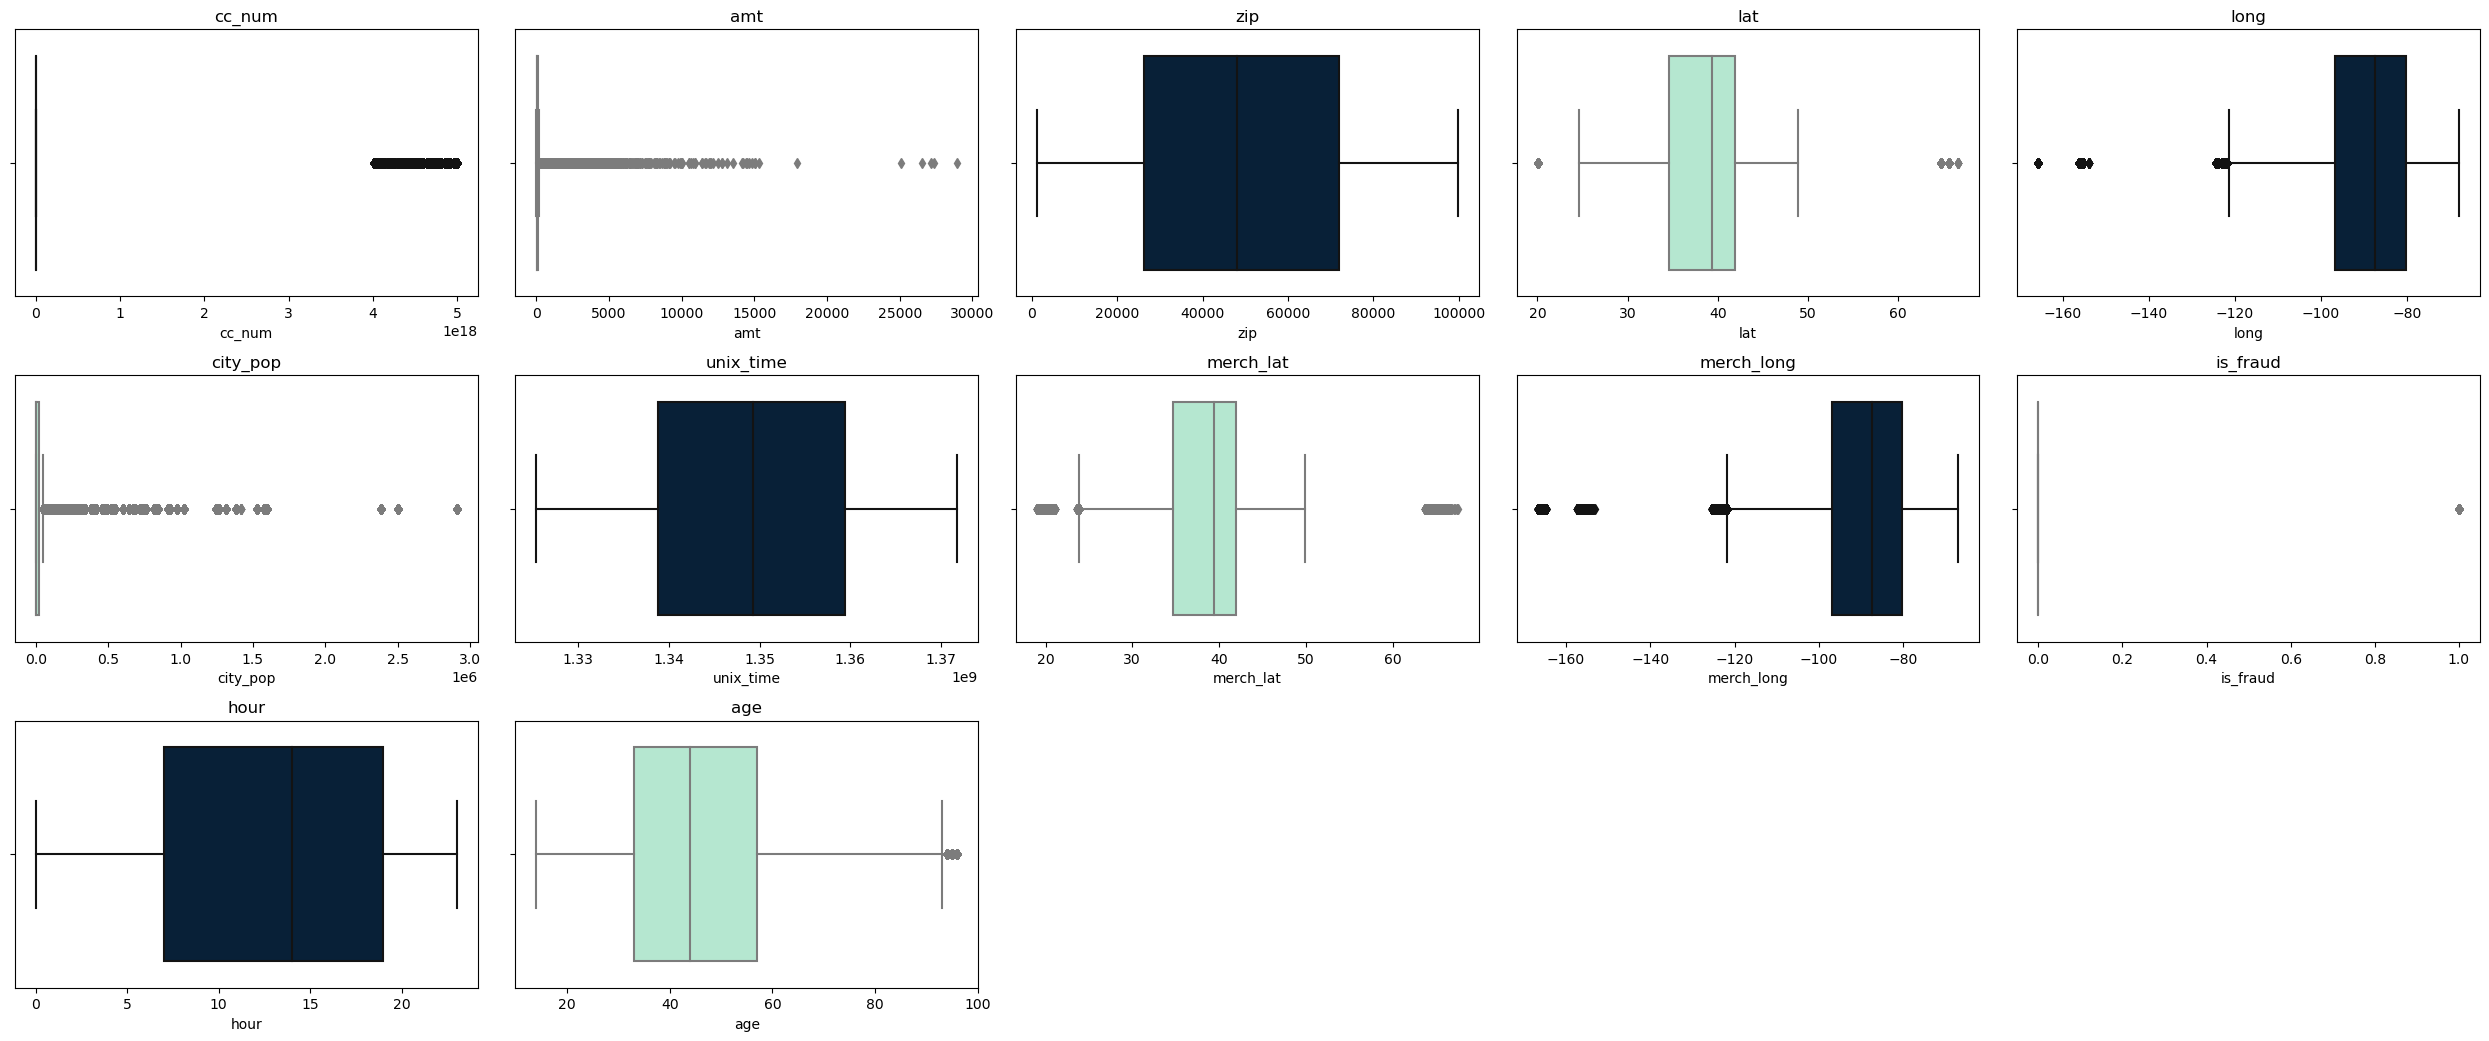

In [23]:
# outlier detection
# Num _COLS 
NUM_COLS_F = [col for col in df.columns if np.issubdtype(df[col].dtype, np.number)]
# Define the number of rows and columns for subplots
num_rows = 5  # 4 rows
num_cols = 5  # 4 columns

# Create subplots with appropriate titles
fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 17))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through each numerical column and create a box plot
palette = ["#00203FFF", "#ADEFD1FF"]
for i, col in enumerate(NUM_COLS_F[:num_rows * num_cols]):
    sns.boxplot(x=df[col], ax=axes[i], color=palette[i % len(palette)])
    axes[i].set_title(col)

# Hide empty subplots
for i in range(len(NUM_COLS_F), num_rows * num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()


## 2. Data Preprocessing and Feature engineering

In [24]:
# importing libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
# importing the dataset
df = pd.read_csv('../../data/raw/FraudTest.csv')

In [25]:
# Feature Engineering: Extracting features from the transaction date and time
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month

In [26]:
# Feature Engineering: Calculating distance between cardholder and merchant locations
def calculate_distance(row):
    lat1, lon1, lat2, lon2 = map(np.radians, [row['lat'], row['long'], row['merch_lat'], row['merch_long']])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = 6371 * c  # Radius of Earth in kilometers
    return distance
df['distance'] = df.apply(calculate_distance, axis=1)

In [27]:
# Selecting relevant features for the model
features = ['amt', 'city_pop', 'hour', 'day', 'day_of_week', 'month', 'distance',
            'merchant', 'category', 'state', 'job', 'gender','city']
X = df[features]
y = df['is_fraud']

In [28]:
# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
# Preprocessing pipeline
numerical_features = ['amt', 'city_pop', 'hour', 'day', 'day_of_week', 'month', 'distance']
categorical_features = ['merchant', 'category', 'state', 'job', 'gender','city']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [30]:
# Preprocessing the training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [31]:
# Display the shape of the preprocessed data
print(X_train_preprocessed.shape, X_test_preprocessed.shape)

(444575, 2093) (111144, 2093)


In [32]:
y_train.shape

(444575,)

In [33]:
y_test.shape

(111144,)

In [34]:
y_train.head()

219591    0
385043    0
270811    0
270180    0
551235    0
Name: is_fraud, dtype: int64

In [35]:
# Export y_train and y_test data to CSV
#y_train.to_csv('y_train.csv', index=False)
#y_test.to_csv('y_test.csv', index=False)

In [36]:
# Convert preprocessed data to DataFrames for exporting
#X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed.toarray())
#X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed.toarray())

# Export preprocessed data to CSV
#X_train_preprocessed_df.to_csv('X_train_preprocessed.csv', index=False)
#X_test_preprocessed_df.to_csv('X_test_preprocessed.csv', index=False)

In [37]:
# feature importance
from sklearn.ensemble import RandomForestClassifier
# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train_preprocessed, y_train)

# Extract feature importance
feature_importances = rf.feature_importances_

In [38]:
# Create a DataFrame for feature importance
feature_names = np.concatenate([numerical_features, preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)])
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

In [39]:
# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 20 features
top_30_features = feature_importance_df.head(30)


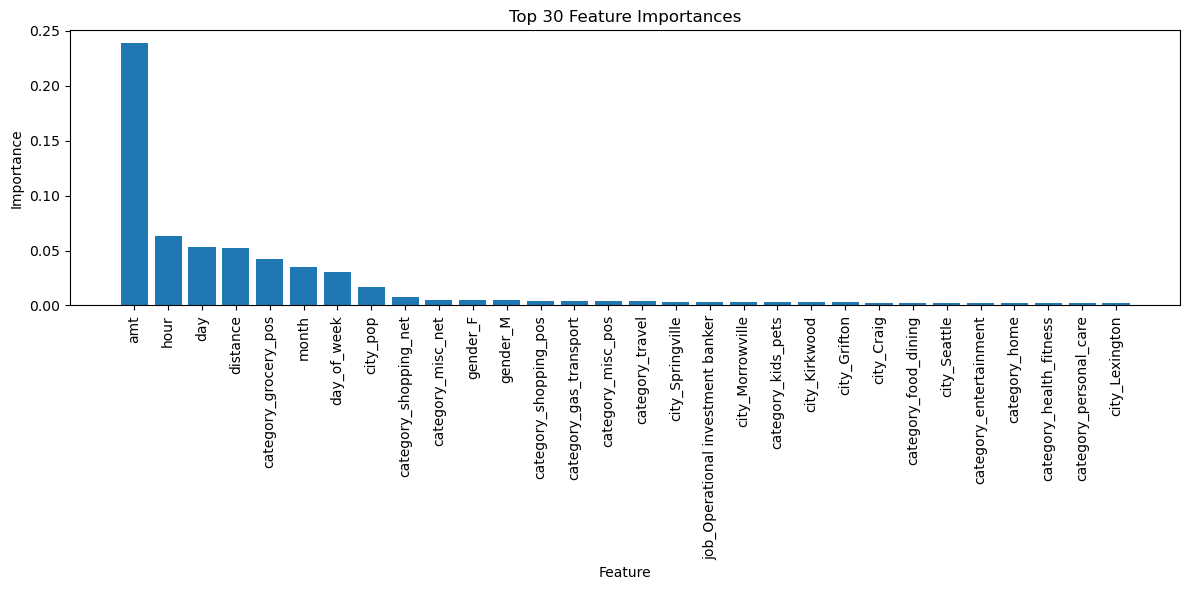

In [40]:
# Plot the top 30 feature importances
plt.figure(figsize=(12, 6))
plt.title("Top 30 Feature Importances")
plt.bar(range(top_30_features.shape[0]), top_30_features['Importance'], align="center")
plt.xticks(range(top_30_features.shape[0]), top_30_features['Feature'], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()

# Model building and Evaluation
## 1- Using smote and random forest on the datasets without feature engineering and removing outliers

In [41]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

# Resampling the training data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_preprocessed, y_train)

# Training a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_resampled, y_resampled)

# Making predictions on the test set
y_pred = rf.predict(X_test_preprocessed)
y_pred_prob = rf.predict_proba(X_test_preprocessed)[:, 1]

# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc}')

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f'PR AUC Score: {pr_auc}')

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.97      0.47      0.63       429

    accuracy                           1.00    111144
   macro avg       0.98      0.74      0.82    111144
weighted avg       1.00      1.00      1.00    111144

ROC-AUC Score: 0.9702890946082925
PR AUC Score: 0.8229934857227853


- The model performs exceptionally well on non-fraud cases with perfect precision, recall, and F1-score.
- For fraud cases, the model has high precision (97%) but relatively low recall (52%). This indicates that while the model is good at correctly predicting frauds when it does predict them, it misses a significant portion of actual fraud cases.
- The high ROC-AUC score suggests that the model is good at distinguishing between fraud and non-fraud instances.
- The PR AUC score is also high, indicating that the model maintains a good balance between precision and recall.
- In the context of credit card fraud detection, having a high precision is crucial because you want to minimize false positives (i.e., flagging legitimate transactions as fraud). However, improving recall is also important to ensure that actual fraud cases are not missed.

## 2- using smote and random forest on datasets that used top 30 features importance 

In [42]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Train a RandomForest to get feature importances
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train_preprocessed, y_train)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort feature importances in descending order

# Create a DataFrame for feature importance
feature_names = np.concatenate([numerical_features, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)])
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Print the DataFrame to check for shape and content
print("Feature Importance DataFrame:")
print(feature_importance_df)

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 30 features
top_30_features = feature_importance_df.head(30)
print("Top 30 Features:")
print(top_30_features)

# Verify shapes and feature names
print("Shape of X_train_preprocessed:", X_train_preprocessed.shape)
print("Shape of X_test_preprocessed:", X_test_preprocessed.shape)
print("Number of feature names:", len(feature_names))
assert X_train_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for training data"
assert X_test_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for test data"

# Extract feature names for the top 30 features
top_30_feature_names = top_30_features['Feature'].values

# Function to cap outliers
def cap_outliers(df, columns):
    for col in columns:
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    return df

# Cap outliers in the training and test datasets
numerical_columns = [col for col in top_30_feature_names if col in numerical_features]
X_train_df = pd.DataFrame(X_train_preprocessed.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed.toarray(), columns=feature_names)

X_train_df = cap_outliers(X_train_df, numerical_columns)
X_test_df = cap_outliers(X_test_df, numerical_columns)

# Select top 30 features from the preprocessed data
X_train_top_features = X_train_df[top_30_feature_names].values
X_test_top_features = X_test_df[top_30_feature_names].values

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_top_features)
X_test_pca = pca.transform(X_test_top_features)

# Resampling the training data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_pca, y_train)

# Training a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_resampled, y_resampled)

# Making predictions on the test set
y_pred = rf.predict(X_test_pca)
y_pred_prob = rf.predict_proba(X_test_pca)[:, 1]

# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc}')

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f'PR AUC Score: {pr_auc}')


Feature Importance DataFrame:
                             Feature  Importance
0                                amt    0.238667
1                           city_pop    0.017064
2                               hour    0.062929
3                                day    0.052971
4                        day_of_week    0.030707
...                              ...         ...
2088                city_Woods Cross    0.000057
2089                  city_Woodville    0.000139
2090  city_Yellowstone National Park    0.000001
2091                    city_Zaleski    0.000001
2092                    city_Zavalla    0.000911

[2093 rows x 2 columns]
Top 30 Features:
                                Feature  Importance
0                                   amt    0.238667
2                                  hour    0.062929
3                                   day    0.052971
6                              distance    0.052298
704                category_grocery_pos    0.042038
5                           

- The model performs very well in terms of overall accuracy and ROC-AUC, indicating it distinguishes well between the two classes.
- Precision for class 1 is relatively low (0.54), indicating that there are quite a few false positives for the minority class.
- Recall for class 1 is better (0.73), suggesting the model is relatively good at identifying actual fraud cases, but there are still some it misses.
- The F1-score for class 1 (0.62) suggests a balance between precision and recall, but there is room for improvement.
- The macro average shows that the model’s performance across classes is not as strong for the minority class.
- The weighted average indicates that the high number of class 0 instances is driving the high overall metrics.

### without using pca but using 30 features

In [43]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Train a RandomForest to get feature importances
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train_preprocessed, y_train)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort feature importances in descending order

# Create a DataFrame for feature importance
feature_names = np.concatenate([numerical_features, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)])
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Print the DataFrame to check for shape and content
print("Feature Importance DataFrame:")
print(feature_importance_df)

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 30 features
top_30_features = feature_importance_df.head(30)
print("Top 30 Features:")
print(top_30_features)

# Verify shapes and feature names
print("Shape of X_train_preprocessed:", X_train_preprocessed.shape)
print("Shape of X_test_preprocessed:", X_test_preprocessed.shape)
print("Number of feature names:", len(feature_names))
assert X_train_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for training data"
assert X_test_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for test data"

# Extract feature names for the top 30 features
top_30_feature_names = top_30_features['Feature'].values

# Function to cap outliers
def cap_outliers(df, columns):
    for col in columns:
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    return df

# Cap outliers in the training and test datasets
numerical_columns = [col for col in top_30_feature_names if col in numerical_features]
X_train_df = pd.DataFrame(X_train_preprocessed.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed.toarray(), columns=feature_names)

X_train_df = cap_outliers(X_train_df, numerical_columns)
X_test_df = cap_outliers(X_test_df, numerical_columns)

# Select top 30 features from the preprocessed data
X_train_top_features = X_train_df[top_30_feature_names].values
X_test_top_features = X_test_df[top_30_feature_names].values

# Apply PCA to reduce dimensionality
#pca = PCA(n_components=0.95)  # Retain 95% of variance
#X_train_pca = pca.fit_transform(X_train_top_features)
#X_test_pca = pca.transform(X_test_top_features)

# Resampling the training data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_top_features, y_train)

# Training a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_resampled, y_resampled)

# Making predictions on the test set
y_pred = rf.predict(X_test_top_features)
y_pred_prob = rf.predict_proba(X_test_top_features)[:, 1]

# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc}')

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f'PR AUC Score: {pr_auc}')


Feature Importance DataFrame:
                             Feature  Importance
0                                amt    0.238667
1                           city_pop    0.017064
2                               hour    0.062929
3                                day    0.052971
4                        day_of_week    0.030707
...                              ...         ...
2088                city_Woods Cross    0.000057
2089                  city_Woodville    0.000139
2090  city_Yellowstone National Park    0.000001
2091                    city_Zaleski    0.000001
2092                    city_Zavalla    0.000911

[2093 rows x 2 columns]
Top 30 Features:
                                Feature  Importance
0                                   amt    0.238667
2                                  hour    0.062929
3                                   day    0.052971
6                              distance    0.052298
704                category_grocery_pos    0.042038
5                           

- Higher Recall and F1-Score: Without PCA but using Random Forest feature selection, the model shows higher recall and F1-score - for the minority class, which is crucial for detecting fraud cases.
- Better PR AUC: The PR AUC score is higher without PCA, suggesting a better performance in terms of precision-recall trade-off.
- ROC-AUC: Both approaches show a high ROC-AUC score, indicating good overall model performance.

### Using top 50 features

In [44]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Train a RandomForest to get feature importances
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train_preprocessed, y_train)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort feature importances in descending order

# Create a DataFrame for feature importance
feature_names = np.concatenate([numerical_features, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)])
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Print the DataFrame to check for shape and content
print("Feature Importance DataFrame:")
print(feature_importance_df)

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 50 features
top_50_features = feature_importance_df.head(50)
print("Top 50 Features:")
print(top_50_features)

# Verify shapes and feature names
print("Shape of X_train_preprocessed:", X_train_preprocessed.shape)
print("Shape of X_test_preprocessed:", X_test_preprocessed.shape)
print("Number of feature names:", len(feature_names))
assert X_train_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for training data"
assert X_test_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for test data"

# Extract feature names for the top 50 features
top_50_feature_names = top_50_features['Feature'].values

# Function to cap outliers
def cap_outliers(df, columns):
    for col in columns:
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    return df

# Cap outliers in the training and test datasets
numerical_columns = [col for col in top_50_feature_names if col in numerical_features]
X_train_df = pd.DataFrame(X_train_preprocessed.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed.toarray(), columns=feature_names)

X_train_df = cap_outliers(X_train_df, numerical_columns)
X_test_df = cap_outliers(X_test_df, numerical_columns)

# Select top 30 features from the preprocessed data
X_train_top_features = X_train_df[top_50_feature_names].values
X_test_top_features = X_test_df[top_50_feature_names].values

# Apply PCA to reduce dimensionality
#pca = PCA(n_components=0.95)  # Retain 95% of variance
#X_train_pca = pca.fit_transform(X_train_top_features)
#X_test_pca = pca.transform(X_test_top_features)

# Resampling the training data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_top_features, y_train)

# Training a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_resampled, y_resampled)

# Making predictions on the test set
y_pred = rf.predict(X_test_top_features)
y_pred_prob = rf.predict_proba(X_test_top_features)[:, 1]

# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc}')

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f'PR AUC Score: {pr_auc}')


Feature Importance DataFrame:
                             Feature  Importance
0                                amt    0.238667
1                           city_pop    0.017064
2                               hour    0.062929
3                                day    0.052971
4                        day_of_week    0.030707
...                              ...         ...
2088                city_Woods Cross    0.000057
2089                  city_Woodville    0.000139
2090  city_Yellowstone National Park    0.000001
2091                    city_Zaleski    0.000001
2092                    city_Zavalla    0.000911

[2093 rows x 2 columns]
Top 50 Features:
                                Feature  Importance
0                                   amt    0.238667
2                                  hour    0.062929
3                                   day    0.052971
6                              distance    0.052298
704                category_grocery_pos    0.042038
5                           

### Using top 100 features

In [45]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Train a RandomForest to get feature importances
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train_preprocessed, y_train)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort feature importances in descending order

# Create a DataFrame for feature importance
feature_names = np.concatenate([numerical_features, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)])
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Print the DataFrame to check for shape and content
print("Feature Importance DataFrame:")
print(feature_importance_df)

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 100 features
top_50_features = feature_importance_df.head(100)
print("Top 100 Features:")
print(top_50_features)

# Verify shapes and feature names
print("Shape of X_train_preprocessed:", X_train_preprocessed.shape)
print("Shape of X_test_preprocessed:", X_test_preprocessed.shape)
print("Number of feature names:", len(feature_names))
assert X_train_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for training data"
assert X_test_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for test data"

# Extract feature names for the top 100 features
top_50_feature_names = top_50_features['Feature'].values

# Function to cap outliers
def cap_outliers(df, columns):
    for col in columns:
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    return df

# Cap outliers in the training and test datasets
numerical_columns = [col for col in top_50_feature_names if col in numerical_features]
X_train_df = pd.DataFrame(X_train_preprocessed.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed.toarray(), columns=feature_names)

X_train_df = cap_outliers(X_train_df, numerical_columns)
X_test_df = cap_outliers(X_test_df, numerical_columns)

# Select top 30 features from the preprocessed data
X_train_top_features = X_train_df[top_50_feature_names].values
X_test_top_features = X_test_df[top_50_feature_names].values

# Apply PCA to reduce dimensionality
#pca = PCA(n_components=0.95)  # Retain 95% of variance
#X_train_pca = pca.fit_transform(X_train_top_features)
#X_test_pca = pca.transform(X_test_top_features)

# Resampling the training data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_top_features, y_train)

# Training a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_resampled, y_resampled)

# Making predictions on the test set
y_pred = rf.predict(X_test_top_features)
y_pred_prob = rf.predict_proba(X_test_top_features)[:, 1]

# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc}')

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f'PR AUC Score: {pr_auc}')

Feature Importance DataFrame:
                             Feature  Importance
0                                amt    0.238667
1                           city_pop    0.017064
2                               hour    0.062929
3                                day    0.052971
4                        day_of_week    0.030707
...                              ...         ...
2088                city_Woods Cross    0.000057
2089                  city_Woodville    0.000139
2090  city_Yellowstone National Park    0.000001
2091                    city_Zaleski    0.000001
2092                    city_Zavalla    0.000911

[2093 rows x 2 columns]
Top 100 Features:
                                 Feature  Importance
0                                    amt    0.238667
2                                   hour    0.062929
3                                    day    0.052971
6                               distance    0.052298
704                 category_grocery_pos    0.042038
...                  

- top 100 features has the over all best scores so far

### Using top 150 features

In [46]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Train a RandomForest to get feature importances
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train_preprocessed, y_train)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort feature importances in descending order

# Create a DataFrame for feature importance
feature_names = np.concatenate([numerical_features, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)])
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Print the DataFrame to check for shape and content
print("Feature Importance DataFrame:")
print(feature_importance_df)

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 150 features
top_50_features = feature_importance_df.head(150)
print("Top 150 Features:")
print(top_50_features)

# Verify shapes and feature names
print("Shape of X_train_preprocessed:", X_train_preprocessed.shape)
print("Shape of X_test_preprocessed:", X_test_preprocessed.shape)
print("Number of feature names:", len(feature_names))
assert X_train_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for training data"
assert X_test_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for test data"

# Extract feature names for the top 150 features
top_50_feature_names = top_50_features['Feature'].values

# Function to cap outliers
def cap_outliers(df, columns):
    for col in columns:
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    return df

# Cap outliers in the training and test datasets
numerical_columns = [col for col in top_50_feature_names if col in numerical_features]
X_train_df = pd.DataFrame(X_train_preprocessed.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed.toarray(), columns=feature_names)

X_train_df = cap_outliers(X_train_df, numerical_columns)
X_test_df = cap_outliers(X_test_df, numerical_columns)

# Select top 30 features from the preprocessed data
X_train_top_features = X_train_df[top_50_feature_names].values
X_test_top_features = X_test_df[top_50_feature_names].values

# Apply PCA to reduce dimensionality
#pca = PCA(n_components=0.95)  # Retain 95% of variance
#X_train_pca = pca.fit_transform(X_train_top_features)
#X_test_pca = pca.transform(X_test_top_features)

# Resampling the training data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_top_features, y_train)

# Training a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_resampled, y_resampled)

# Making predictions on the test set
y_pred = rf.predict(X_test_top_features)
y_pred_prob = rf.predict_proba(X_test_top_features)[:, 1]

# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc}')

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f'PR AUC Score: {pr_auc}')

Feature Importance DataFrame:
                             Feature  Importance
0                                amt    0.238667
1                           city_pop    0.017064
2                               hour    0.062929
3                                day    0.052971
4                        day_of_week    0.030707
...                              ...         ...
2088                city_Woods Cross    0.000057
2089                  city_Woodville    0.000139
2090  city_Yellowstone National Park    0.000001
2091                    city_Zaleski    0.000001
2092                    city_Zavalla    0.000911

[2093 rows x 2 columns]
Top 150 Features:
                                        Feature  Importance
0                                           amt    0.238667
2                                          hour    0.062929
3                                           day    0.052971
6                                      distance    0.052298
704                        category_gro

- 150 top features had better precicion but less recall scores 

### Using the top 300 features

In [47]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Train a RandomForest to get feature importances
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train_preprocessed, y_train)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort feature importances in descending order

# Create a DataFrame for feature importance
feature_names = np.concatenate([numerical_features, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)])
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Print the DataFrame to check for shape and content
print("Feature Importance DataFrame:")
print(feature_importance_df)

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 300 features
top_50_features = feature_importance_df.head(300)
print("Top 50 Features:")
print(top_50_features)

# Verify shapes and feature names
print("Shape of X_train_preprocessed:", X_train_preprocessed.shape)
print("Shape of X_test_preprocessed:", X_test_preprocessed.shape)
print("Number of feature names:", len(feature_names))
assert X_train_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for training data"
assert X_test_preprocessed.shape[1] == len(feature_names), "Mismatch in number of features for test data"

# Extract feature names for the top 300 features
top_50_feature_names = top_50_features['Feature'].values

# Function to cap outliers
def cap_outliers(df, columns):
    for col in columns:
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    return df

# Cap outliers in the training and test datasets
numerical_columns = [col for col in top_50_feature_names if col in numerical_features]
X_train_df = pd.DataFrame(X_train_preprocessed.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed.toarray(), columns=feature_names)

X_train_df = cap_outliers(X_train_df, numerical_columns)
X_test_df = cap_outliers(X_test_df, numerical_columns)

# Select top 30 features from the preprocessed data
X_train_top_features = X_train_df[top_50_feature_names].values
X_test_top_features = X_test_df[top_50_feature_names].values

# Apply PCA to reduce dimensionality
#pca = PCA(n_components=0.95)  # Retain 95% of variance
#X_train_pca = pca.fit_transform(X_train_top_features)
#X_test_pca = pca.transform(X_test_top_features)

# Resampling the training data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_top_features, y_train)

# Training a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_resampled, y_resampled)

# Making predictions on the test set
y_pred = rf.predict(X_test_top_features)
y_pred_prob = rf.predict_proba(X_test_top_features)[:, 1]

# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc}')

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f'PR AUC Score: {pr_auc}')

Feature Importance DataFrame:
                             Feature  Importance
0                                amt    0.238667
1                           city_pop    0.017064
2                               hour    0.062929
3                                day    0.052971
4                        day_of_week    0.030707
...                              ...         ...
2088                city_Woods Cross    0.000057
2089                  city_Woodville    0.000139
2090  city_Yellowstone National Park    0.000001
2091                    city_Zaleski    0.000001
2092                    city_Zavalla    0.000911

[2093 rows x 2 columns]
Top 50 Features:
                          Feature  Importance
0                             amt    0.238667
2                            hour    0.062929
3                             day    0.052971
6                        distance    0.052298
704          category_grocery_pos    0.042038
...                           ...         ...
1448              

- 300 top compared to 150, the increase is not significant but rather reduce more recall

## 3- using pca with 95% variance and without using feature selections on frandom forest

In [48]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

# Assuming the following variables are already defined:
# X_train_preprocessed, y_train, X_test_preprocessed, y_test, feature_names

# Function to cap outliers
def cap_outliers(df, columns):
    for col in columns:
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    return df

# Cap outliers in the training and test datasets
numerical_columns = [col for col in feature_names if col in numerical_features]
X_train_df = pd.DataFrame(X_train_preprocessed.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed.toarray(), columns=feature_names)

X_train_df = cap_outliers(X_train_df, numerical_columns)
X_test_df = cap_outliers(X_test_df, numerical_columns)

# Apply PCA to reduce dimensionality on the entire feature set
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca_full = pca.fit_transform(X_train_df.values)
X_test_pca_full = pca.transform(X_test_df.values)

# Resampling the training data using SMOTE
smote = SMOTE(random_state=42)
X_resampled_full, y_resampled_full = smote.fit_resample(X_train_pca_full, y_train)

# Training a RandomForestClassifier
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_resampled_full, y_resampled_full)

# Making predictions on the test set
y_pred_full = rf.predict(X_test_pca_full)
y_pred_prob_full = rf.predict_proba(X_test_pca_full)[:, 1]

# Evaluating the model
print("Classification Report with PCA on all features:\n", classification_report(y_test, y_pred_full))
roc_auc_full = roc_auc_score(y_test, y_pred_prob_full)
print(f'ROC-AUC Score with PCA on all features: {roc_auc_full}')

precision_full, recall_full, _ = precision_recall_curve(y_test, y_pred_prob_full)
pr_auc_full = auc(recall_full, precision_full)
print(f'PR AUC Score with PCA on all features: {pr_auc_full}')


Classification Report with PCA on all features:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.86      0.56      0.68       429

    accuracy                           1.00    111144
   macro avg       0.93      0.78      0.84    111144
weighted avg       1.00      1.00      1.00    111144

ROC-AUC Score with PCA on all features: 0.9579501201503641
PR AUC Score with PCA on all features: 0.7199430976987528


- Using pca with retaining 95% variance on all the features, had worse recall than using top 100 features while the computational time was significantly higher

In [54]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from scipy.sparse import csr_matrix

# Load the dataset
df = pd.read_csv('../../data/raw/FraudTest.csv')

# Feature Engineering: Extracting features from the transaction date and time
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month

# Feature Engineering: Calculating distance between cardholder and merchant locations
def calculate_distance(row):
    lat1, lon1, lat2, lon2 = map(np.radians, [row['lat'], row['long'], row['merch_lat'], row['merch_long']])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = 6371 * c  # Radius of Earth in kilometers
    return distance

df['distance'] = df.apply(calculate_distance, axis=1)

# Selecting relevant features for the model
features = ['amt', 'city_pop', 'hour', 'day', 'day_of_week', 'month', 'distance',
            'merchant', 'category', 'state', 'job', 'gender', 'city']
X = df[features]
y = df['is_fraud']

# Preprocessing pipeline
numerical_features = ['amt', 'city_pop', 'hour', 'day', 'day_of_week', 'month', 'distance']
categorical_features = ['merchant', 'category', 'state', 'job', 'gender', 'city']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Preprocessing the test data
X_test_preprocessed = preprocessor.fit_transform(X)

# Cap outliers in the test dataset
def cap_outliers(df, columns):
    for col in columns:
        lower_cap = df[col].quantile(0.01)
        upper_cap = df[col].quantile(0.99)
        df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
        df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    return df

# Converting sparse matrix to DataFrame in chunks to avoid memory errors
chunk_size = 10000  # Define a chunk size
chunks = []
num_chunks = X_test_preprocessed.shape[0] // chunk_size + 1

feature_names = preprocessor.get_feature_names_out()
for i in range(num_chunks):
    start = i * chunk_size
    end = (i + 1) * chunk_size
    chunk = pd.DataFrame(X_test_preprocessed[start:end].toarray(), columns=feature_names)
    chunk = cap_outliers(chunk, [f'num__{col}' for col in numerical_features])
    chunks.append(chunk)

X_test_df = pd.concat(chunks, ignore_index=True)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_test_pca = pca.fit_transform(X_test_df.values)

# Load the trained RandomForest model
# Example: from joblib import load
# rf = load('path_to_model/random_forest_model.joblib')

# Making predictions on the test set
y_pred = rf.predict(X_test_pca)
y_pred_prob = rf.predict_proba(X_test_pca)[:, 1]

# Evaluating the model
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_pred_prob)
precision_vals, recall_vals, _ = precision_recall_curve(y, y_pred_prob)
pr_auc = auc(recall_vals, precision_vals)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR AUC: {pr_auc:.4f}')
print("Classification Report:")
print(classification_report(y, y_pred))


MemoryError: Unable to allocate 8.64 GiB for an array with shape (2086, 555719) and data type float64